# Task 1: Inductive Biases and Feature Representations


In [1]:
!pip install -q open_clip_torch umap-learn tqdm scikit-learn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights, vgg19, VGG19_Weights
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm
import open_clip
import json
from sklearn.metrics import f1_score, accuracy_score
from sklearn.manifold import TSNE
import umap
import copy


In [3]:
SEED = 6304

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


Using device: cuda


In [4]:
# STL-10 dataset
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=base_transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=base_transform)

# Stratified 80/20 train/val split
train_indices, val_indices = [], []
from collections import defaultdict
class_indices = defaultdict(list)
for i, (_, label) in enumerate(train_dataset):
    class_indices[label].append(i)

for label, indices in class_indices.items():
    np.random.shuffle(indices)
    split = int(0.8 * len(indices))
    train_indices.extend(indices[:split])
    val_indices.extend(indices[split:])

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

# Class-balanced subset of 500 test images
test_class_indices = defaultdict(list)
for i, (_, label) in enumerate(test_dataset):
    test_class_indices[label].append(i)

test_500_indices = []
for label, indices in test_class_indices.items():
    np.random.shuffle(indices)
    test_500_indices.extend(indices[:50]) # 50 per class

test_subset = Subset(test_dataset, test_500_indices)

with open('results/test_500_indices.json', 'w') as f:
    json.dump(test_500_indices, f)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)
print("Data loaded.")


100%|██████████| 2.64G/2.64G [06:50<00:00, 6.43MB/s]


Data loaded.


In [5]:
# Models Setup
resnet_norm = ResNet50_Weights.IMAGENET1K_V2.transforms()
vit_norm = ViT_B_16_Weights.IMAGENET1K_V1.transforms()
_, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_norm = transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))

class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone.fc = nn.Identity()
        for param in self.parameters():
            param.requires_grad = False
        self.eval()
    def forward(self, x):
        return self.backbone(x)

class ViTFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.backbone.heads = nn.Identity()
        for param in self.parameters():
            param.requires_grad = False
        self.eval()
    def forward(self, x):
        return self.backbone(x)

class CLIPFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
        for param in self.parameters():
            param.requires_grad = False
        self.eval()
    def forward(self, x):
        return self.model.encode_image(x)

resnet_fe = ResNetFeatureExtractor().to(device)
vit_fe = ViTFeatureExtractor().to(device)
clip_fe = CLIPFeatureExtractor().to(device)

def get_norm(name):
    if name == 'resnet': return transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if name == 'vit': return transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if name == 'clip': return clip_norm

models_dict = {
    'resnet': (resnet_fe, get_norm('resnet'), 2048),
    'vit': (vit_fe, get_norm('vit'), 768),
    'clip': (clip_fe, get_norm('clip'), 512)
}

# Zero-shot CLIP setup
clip_model = clip_fe.model
tokenizer = open_clip.get_tokenizer('ViT-B-32')
text_prompts = [f"a photo of a {c}." for c in class_names]
text_tokens = tokenizer(text_prompts).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)



open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 173MB/s]


In [6]:
# TIME ESTIMATE: ~5-10 minutes for feature extraction and training
def extract_features(loader, model_name):
    fe, norm, _ = models_dict[model_name]
    fe.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f'Extracting {model_name} features', leave=False):
            x = norm(x).to(device)
            f = fe(x)
            features.append(f.cpu())
            labels.append(y)
    return torch.cat(features), torch.cat(labels)

heads = {}
for name in ['resnet', 'vit', 'clip']:
    dim = models_dict[name][2]
    head = nn.Linear(dim, 10).to(device)
    heads[name] = head

    train_f, train_y = extract_features(train_loader, name)
    val_f, val_y = extract_features(val_loader, name)
    
    train_ds = torch.utils.data.TensorDataset(train_f, train_y)
    val_ds = torch.utils.data.TensorDataset(val_f, val_y)
    
    tl = DataLoader(train_ds, batch_size=128, shuffle=True)
    vl = DataLoader(val_ds, batch_size=128, shuffle=False)
    
    optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    best_acc = 0.0
    patience = 5
    wait = 0
    
    for epoch in range(50):
        head.train()
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = head(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
        head.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(device), y.to(device)
                out = head(x)
                pred = out.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            torch.save(head.state_dict(), f'results/{name}_head.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"{name} early stopping at epoch {epoch+1}")
                break
                
    head.load_state_dict(torch.load(f'results/{name}_head.pt'))



Extracting resnet features:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting resnet features:   0%|          | 0/32 [00:00<?, ?it/s]

resnet early stopping at epoch 17


Extracting vit features:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting vit features:   0%|          | 0/32 [00:00<?, ?it/s]

vit early stopping at epoch 16


Extracting clip features:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting clip features:   0%|          | 0/32 [00:00<?, ?it/s]

clip early stopping at epoch 11


## 1. Clean Baseline


In [7]:
def evaluate_models(loader, transform_fn=None):
    results = {'resnet': {'y_true': [], 'y_pred': [], 'conf': []},
               'vit': {'y_true': [], 'y_pred': [], 'conf': []},
               'clip': {'y_true': [], 'y_pred': [], 'conf': []},
               'clip_zs': {'y_true': [], 'y_pred': [], 'conf': []}}
               
    for name in ['resnet', 'vit', 'clip']:
        heads[name].eval()
        
    with torch.no_grad():
        for x, y in tqdm(loader, desc='Evaluating'):
            if transform_fn is not None:
                x = transform_fn(x)
                
            for name in ['resnet', 'vit', 'clip']:
                fe, norm, _ = models_dict[name]
                x_norm = norm(x).to(device)
                f = fe(x_norm)
                out = heads[name](f)
                probs = F.softmax(out, dim=1)
                conf, pred = probs.max(dim=1)
                
                results[name]['y_true'].extend(y.tolist())
                results[name]['y_pred'].extend(pred.cpu().tolist())
                results[name]['conf'].extend(conf.cpu().tolist())
                
            # CLIP zero-shot
            _, norm, _ = models_dict['clip']
            x_norm = norm(x).to(device)
            image_features = clip_model.encode_image(x_norm)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            similarity = (100.0 * image_features @ text_features.T)
            probs = F.softmax(similarity, dim=1)
            conf, pred = probs.max(dim=1)
            
            results['clip_zs']['y_true'].extend(y.tolist())
            results['clip_zs']['y_pred'].extend(pred.cpu().tolist())
            results['clip_zs']['conf'].extend(conf.cpu().tolist())
            
    return results

clean_results = evaluate_models(test_loader)

baseline_metrics = []
for model, res in clean_results.items():
    acc = accuracy_score(res['y_true'], res['y_pred'])
    f1 = f1_score(res['y_true'], res['y_pred'], average='macro')
    mean_conf = np.mean(res['conf'])
    baseline_metrics.append({'Model': model, 'Accuracy': acc, 'Macro-F1': f1, 'Mean Conf': mean_conf})

df_baseline = pd.DataFrame(baseline_metrics)
df_baseline.to_csv('results/task1_clean_baseline.csv', index=False)
display(df_baseline)



Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Accuracy,Macro-F1,Mean Conf
0,resnet,0.976,0.975998,0.942077
1,vit,0.970,0.970071,0.967429
2,clip,0.978,0.977995,0.896086
3,clip_zs,0.942,0.940071,0.931604


## 2. Color Bias


In [8]:
import torchvision.transforms.functional as TF

def grayscale_transform(x):
    return TF.rgb_to_grayscale(x, num_output_channels=3)

def hue_rotation_transform(x):
    # Rotate hue by 90 degrees (which is 0.25 out of range [-0.5, 0.5])
    return TF.adjust_hue(x, 0.25)

gray_results = evaluate_models(test_loader, transform_fn=grayscale_transform)
hue_results = evaluate_models(test_loader, transform_fn=hue_rotation_transform)

color_metrics = []
for model in clean_results.keys():
    clean_acc = df_baseline[df_baseline['Model'] == model]['Accuracy'].values[0]
    
    gray_acc = accuracy_score(gray_results[model]['y_true'], gray_results[model]['y_pred'])
    gray_cons = np.mean(np.array(gray_results[model]['y_pred']) == np.array(clean_results[model]['y_pred']))
    
    hue_acc = accuracy_score(hue_results[model]['y_true'], hue_results[model]['y_pred'])
    hue_cons = np.mean(np.array(hue_results[model]['y_pred']) == np.array(clean_results[model]['y_pred']))
    
    color_metrics.append({
        'Model': model,
        'Grayscale Acc Drop': clean_acc - gray_acc,
        'Grayscale Consistency': gray_cons,
        'Hue Acc Drop': clean_acc - hue_acc,
        'Hue Consistency': hue_cons
    })

df_color = pd.DataFrame(color_metrics)
df_color.to_csv('results/task1_color_bias.csv', index=False)
display(df_color)



Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Grayscale Acc Drop,Grayscale Consistency,Hue Acc Drop,Hue Consistency
0,resnet,0.026,0.962,0.044,0.936
1,vit,0.016,0.964,0.032,0.950
2,clip,0.042,0.938,0.050,0.930
3,clip_zs,0.030,0.926,0.022,0.924


## 3. Shape vs Texture (Cue Conflicts)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 224MB/s]


Generating pairs:   0%|          | 0/5 [00:00<?, ?it/s]

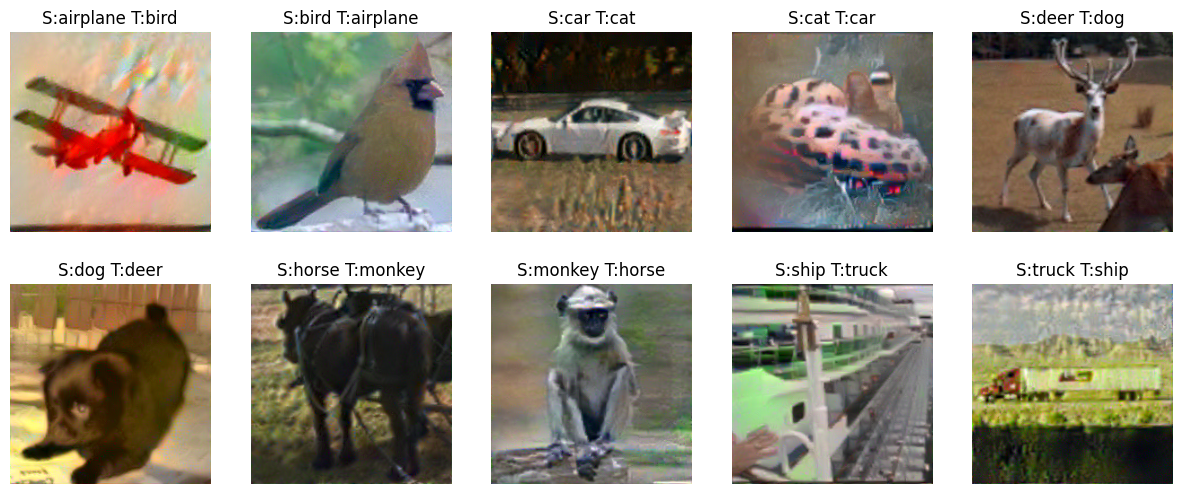

Evaluating Conflicts:   0%|          | 0/7 [00:00<?, ?it/s]

,Model,Shape Bias (%),Coverage (%)
0,resnet,95.767196,94.5
1,vit,97.326203,93.5
2,clip,96.703297,91.0
3,clip_zs,96.045198,88.5


In [9]:
# TIME ESTIMATE: ~20-30 minutes to generate cue conflict images via iterative optimization
vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features[:21].to(device).eval()
vgg_full = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg_full.parameters(): p.requires_grad = False
for p in vgg.parameters(): p.requires_grad = False
vgg_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def calc_mean_std(feat, eps=1e-5):
    size = feat.size()
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

def adain(content_feat, style_feat):
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)
    normalized_feat = (content_feat - content_mean.expand(size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)

def generate_cue_conflict(content_img, style_img, steps=300, alpha=1.0, beta=1e4):
    content_img = content_img.unsqueeze(0).to(device)
    style_img   = style_img.unsqueeze(0).to(device)
    target_img  = content_img.clone().requires_grad_(True)
    optimizer   = torch.optim.LBFGS([target_img], lr=1.0)  # LBFGS converges faster than Adam here

    # Use multiple style layers
    style_layers   = [3, 8, 17, 26]   # relu1_2, relu2_2, relu3_4, relu4_4 in VGG19
    content_layers = [26]

    def gram(feat):
        b, c, h, w = feat.shape
        f = feat.view(b, c, -1)
        return f @ f.transpose(1, 2) / (c * h * w)

    def get_activations(img, layers):
        acts = {}
        x = vgg_norm(img)
        for i, layer in enumerate(vgg_full):  # use full vgg19.features
            x = layer(x)
            if i in layers:
                acts[i] = x
        return acts

    with torch.no_grad():
        style_acts   = get_activations(style_img, style_layers)
        content_acts = get_activations(content_img, content_layers)
        style_grams  = {l: gram(a) for l, a in style_acts.items()}

    def closure():
        optimizer.zero_grad()
        target_acts = get_activations(target_img.clamp(0, 1), style_layers + content_layers)
        
        style_loss   = sum(F.mse_loss(gram(target_acts[l]), style_grams[l]) for l in style_layers)
        content_loss = sum(F.mse_loss(target_acts[l], content_acts[l]) for l in content_layers)
        
        loss = alpha * content_loss + beta * style_loss
        loss.backward()
        return loss

    for _ in range(steps):
        optimizer.step(closure)
        target_img.data.clamp_(0, 1)

    return target_img.detach().squeeze(0).cpu()
# Select 5 unordered pairs => 10 directed pairs
pairs = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
conflict_images = []
conflict_shape_labels = []
conflict_texture_labels = []

# Collect one representative image for each class from the test subset
class_reps = {}
for x, y in test_subset:
    if y not in class_reps:
        class_reps[y] = x
    if len(class_reps) == 10:
        break

# Generate conflicts (20 per directed pair => 200 total)
for shape_cls, texture_cls in tqdm(pairs, desc='Generating pairs'):
    # direction 1: shape=shape_cls, texture=texture_cls
    for i in range(20):
        # random images of these classes
        shape_img = test_subset[np.random.choice([idx for idx, (_, y) in enumerate(test_subset) if y == shape_cls])][0]
        texture_img = test_subset[np.random.choice([idx for idx, (_, y) in enumerate(test_subset) if y == texture_cls])][0]
        conflict_img = generate_cue_conflict(shape_img, texture_img, steps=30) # fewer steps for speed
        conflict_images.append(conflict_img)
        conflict_shape_labels.append(shape_cls)
        conflict_texture_labels.append(texture_cls)
        
    # direction 2: shape=texture_cls, texture=shape_cls
    for i in range(20):
        shape_img = test_subset[np.random.choice([idx for idx, (_, y) in enumerate(test_subset) if y == texture_cls])][0]
        texture_img = test_subset[np.random.choice([idx for idx, (_, y) in enumerate(test_subset) if y == shape_cls])][0]
        conflict_img = generate_cue_conflict(shape_img, texture_img, steps=30)
        conflict_images.append(conflict_img)
        conflict_shape_labels.append(texture_cls)
        conflict_texture_labels.append(shape_cls)

# Show examples
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axs[i//5, i%5]
    ax.imshow(conflict_images[i*20].detach().permute(1,2,0).clamp(0,1))
    ax.set_title(f"S:{class_names[conflict_shape_labels[i*20]]} T:{class_names[conflict_texture_labels[i*20]]}")
    ax.axis('off')
plt.savefig('figures/task1_cue_conflict_examples.png')
plt.show()

# Evaluate
class ConflictDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, s_labels, t_labels):
        self.imgs = imgs
        self.s_labels = s_labels
        self.t_labels = t_labels
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx): return self.imgs[idx], self.s_labels[idx], self.t_labels[idx]

conflict_loader = DataLoader(ConflictDataset(conflict_images, conflict_shape_labels, conflict_texture_labels), batch_size=32)

conflict_results = {'resnet': [], 'vit': [], 'clip': [], 'clip_zs': []}

for name in ['resnet', 'vit', 'clip']:
    heads[name].eval()

with torch.no_grad():
    for x, s_y, t_y in tqdm(conflict_loader, desc='Evaluating Conflicts'):
        for name in ['resnet', 'vit', 'clip']:
            fe, norm, _ = models_dict[name]
            x_norm = norm(x).to(device)
            f = fe(x_norm)
            out = heads[name](f)
            pred = out.argmax(dim=1).cpu()
            for p, s, t in zip(pred, s_y, t_y):
                conflict_results[name].append((p.item(), s.item(), t.item()))
                
        # CLIP ZS
        _, norm, _ = models_dict['clip']
        x_norm = norm(x).to(device)
        image_features = clip_model.encode_image(x_norm)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T)
        pred = similarity.argmax(dim=1).cpu()
        for p, s, t in zip(pred, s_y, t_y):
            conflict_results['clip_zs'].append((p.item(), s.item(), t.item()))

conflict_metrics = []
for model, res in conflict_results.items():
    n_shape = sum(1 for p, s, t in res if p == s)
    n_texture = sum(1 for p, s, t in res if p == t)
    n_total = len(res)
    shape_bias = n_shape / (n_shape + n_texture + 1e-8) * 100
    coverage = (n_shape + n_texture) / n_total * 100
    conflict_metrics.append({'Model': model, 'Shape Bias (%)': shape_bias, 'Coverage (%)': coverage})

df_conflict = pd.DataFrame(conflict_metrics)
df_conflict.to_csv('results/task1_shape_texture.csv', index=False)
display(df_conflict)



## 4. Translation


Translating 0px


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Translating 8px


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

...

Translating 32px


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

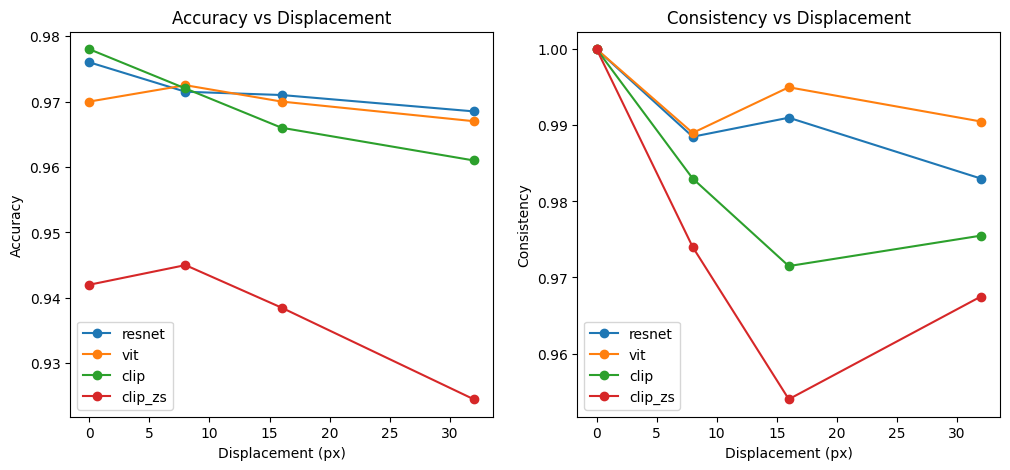

In [10]:
def translate_image(x, dx, dy):
    pad = transforms.Pad((abs(dx), abs(dy)), padding_mode='reflect')
    x_pad = pad(x)
    _, h, w = x.shape
    start_y = abs(dy) - dy
    start_x = abs(dx) - dx
    return TF.crop(x_pad, start_y, start_x, h, w)

displacements = [0, 8, 16, 32]
directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

trans_results = []

for d in displacements:
    print(f"Translating {d}px")
    if d == 0:
        res = evaluate_models(test_loader)
        for model in res.keys():
            acc = accuracy_score(res[model]['y_true'], res[model]['y_pred'])
            trans_results.append({'Model': model, 'Displacement': 0, 'Accuracy': acc, 'Consistency': 1.0})
        continue
        
    model_preds_d = {m: [] for m in ['resnet', 'vit', 'clip', 'clip_zs']}
    model_accs_d = {m: [] for m in ['resnet', 'vit', 'clip', 'clip_zs']}
    
    for dx, dy in directions:
        def t_fn(x):
            return torch.stack([translate_image(img, dx*d, dy*d) for img in x])
        res = evaluate_models(test_loader, transform_fn=t_fn)
        for model in res.keys():
            model_preds_d[model].append(res[model]['y_pred'])
            model_accs_d[model].append(accuracy_score(res[model]['y_true'], res[model]['y_pred']))
            
    for model in model_preds_d.keys():
        avg_acc = np.mean(model_accs_d[model])
        consistencies = []
        for i in range(4):
            cons = np.mean(np.array(model_preds_d[model][i]) == np.array(clean_results[model]['y_pred']))
            consistencies.append(cons)
        avg_cons = np.mean(consistencies)
        trans_results.append({'Model': model, 'Displacement': d, 'Accuracy': avg_acc, 'Consistency': avg_cons})

df_trans = pd.DataFrame(trans_results)
df_trans.to_csv('results/task1_translation.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for model in df_trans['Model'].unique():
    subset = df_trans[df_trans['Model'] == model]
    ax1.plot(subset['Displacement'], subset['Accuracy'], marker='o', label=model)
    ax2.plot(subset['Displacement'], subset['Consistency'], marker='o', label=model)

ax1.set_title('Accuracy vs Displacement')
ax1.set_xlabel('Displacement (px)')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.set_title('Consistency vs Displacement')
ax2.set_xlabel('Displacement (px)')
ax2.set_ylabel('Consistency')
ax2.legend()

plt.savefig('figures/task1_translation_curve.png')
plt.show()



## 5. Patch Structure


In [11]:
def patch_shuffle(x):
    # x is a batch of (C, H, W)
    batch_size, c, h, w = x.shape
    patch_size_h, patch_size_w = h // 4, w // 4
    
    out = torch.zeros_like(x)
    for i in range(batch_size):
        patches = []
        for row in range(4):
            for col in range(4):
                patch = x[i, :, row*patch_size_h:(row+1)*patch_size_h, col*patch_size_w:(col+1)*patch_size_w]
                patches.append(patch)
                
        # Shuffle
        perm = torch.randperm(16)
        while torch.all(perm == torch.arange(16)): # ensure non-identity
            perm = torch.randperm(16)
            
        shuffled_patches = [patches[idx] for idx in perm]
        
        for idx, patch in enumerate(shuffled_patches):
            row, col = idx // 4, idx % 4
            out[i, :, row*patch_size_h:(row+1)*patch_size_h, col*patch_size_w:(col+1)*patch_size_w] = patch
            
    return out

patch_results = evaluate_models(test_loader, transform_fn=patch_shuffle)

patch_metrics = []
for model in clean_results.keys():
    clean_acc = df_baseline[df_baseline['Model'] == model]['Accuracy'].values[0]
    patch_acc = accuracy_score(patch_results[model]['y_true'], patch_results[model]['y_pred'])
    patch_cons = np.mean(np.array(patch_results[model]['y_pred']) == np.array(clean_results[model]['y_pred']))
    
    patch_metrics.append({
        'Model': model,
        'Accuracy Drop': clean_acc - patch_acc,
        'Consistency': patch_cons
    })

df_patch = pd.DataFrame(patch_metrics)
df_patch.to_csv('results/task1_patch_shuffle.csv', index=False)
display(df_patch)



Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Accuracy Drop,Consistency
0,resnet,0.082,0.904
1,vit,0.052,0.930
2,clip,0.182,0.796
3,clip_zs,0.172,0.772


## 6. Representation Analysis


In [12]:
def get_features(loader, model_name, transform_fn=None):
    fe, norm, _ = models_dict[model_name]
    fe.eval()
    features = []
    with torch.no_grad():
        for x, _ in loader:
            if transform_fn: x = transform_fn(x)
            x = norm(x).to(device)
            f = fe(x)
            features.append(f.cpu())
    return torch.cat(features)

def calc_stability(f1, f2):
    f1_norm = f1 / f1.norm(dim=1, keepdim=True)
    f2_norm = f2 / f2.norm(dim=1, keepdim=True)
    return (f1_norm * f2_norm).sum(dim=1).mean().item()

def t32_transform(x): return torch.stack([translate_image(img, 32, 0) for img in x])

transforms_dict = {
    'Grayscale': grayscale_transform,
    'Translation (32px)': t32_transform,
    'Patch Shuffle': patch_shuffle
}

stability_results = []
for model in ['resnet', 'vit', 'clip']:
    f_clean = get_features(test_loader, model)
    for t_name, t_fn in transforms_dict.items():
        f_trans = get_features(test_loader, model, transform_fn=t_fn)
        stab = calc_stability(f_clean, f_trans)
        stability_results.append({'Model': model, 'Transform': t_name, 'Cosine Stability': stab})

df_stab = pd.DataFrame(stability_results)
df_stab.to_csv('results/task1_cosine_stability.csv', index=False)
display(df_stab)

# UMAP / t-SNE Visualization
for model in ['resnet', 'vit', 'clip']:
    f_clean = get_features(test_loader, model).numpy()
    f_gray = get_features(test_loader, model, transform_fn=grayscale_transform).numpy()
    
    labels = np.array(clean_results[model]['y_true'])
    
    combined_f = np.vstack([f_clean, f_gray])
    combined_labels = np.concatenate([labels, labels])
    is_trans = np.concatenate([np.zeros(len(f_clean)), np.ones(len(f_gray))])
    
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    proj = reducer.fit_transform(combined_f)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(proj[:, 0], proj[:, 1], c=combined_labels, cmap='tab10', 
                          marker='o', alpha=0.6)
    
    # Differentiate transformed points by changing marker edge
    plt.scatter(proj[is_trans==1, 0], proj[is_trans==1, 1], c=combined_labels[is_trans==1], 
                cmap='tab10', marker='^', alpha=0.6, edgecolors='black')
                
    plt.title(f'{model.upper()} Feature Space (Circles=Clean, Triangles=Grayscale)')
    plt.colorbar(scatter, ticks=range(10), label='Classes')
    plt.savefig(f'figures/task1_tsne_{model}.png')
    plt.close()



,Model,Transform,Cosine Stability
0,resnet,Grayscale,0.803555
1,resnet,Translation (32px),0.920175
2,resnet,Patch Shuffle,0.699822
3,vit,Grayscale,0.733063
4,vit,Translation (32px),0.949065
5,vit,Patch Shuffle,0.630140
6,clip,Grayscale,0.885884
7,clip,Translation (32px),0.959954
8,clip,Patch Shuffle,0.754115


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
# kaggle output cleanup to avoid 6gig output download 
import shutil

# Remove STL-10 dataset binaries
shutil.rmtree('./data', ignore_errors=True)

# Remove saved model weights
for name in ['resnet', 'vit', 'clip']:
    path = f'results/{name}_head.pt'
    if os.path.exists(path):
        os.remove(path)

print("Cleaned up.")

Cleaned up.
